In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
df = pd.read_csv(r'../pre-calculated_data/bgc_region_len_gtdb.tsv',sep='\t',header=None,names=['bgc','type','category','start','end','length','mag','gtdb','domain','phylum','class','order','family','genus','species'])
df

,bgc,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__


In [4]:
df['category'] = df['category'].apply(lambda x: 'hybrid' if isinstance(x, str) and '.' in x else x)
df

,bgc,type,category,start,end,length,mag,gtdb,domain,phylum,class,order,family,genus,species
0,snj13_SemiBin_61.fa_contig_6398_polypolish.reg...,RRE-containing,RiPP,16888,31236,14349,snj13_SemiBin_61,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Ferrovibrionales,f__Ferrovibrionaceae,g__Desertibaculum,s__
1,cpsnj02_SemiBin_18.fa_contig_6985_polypolish.r...,arylpolyene,other,1400180,1441370,41191,cpsnj02_SemiBin_18,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__DASXSB01,s__
2,snj08_SemiBin_1011.fa_contig_3158_polypolish.r...,terpene,terpene,52049,73981,21933,snj08_SemiBin_1011,d__Bacteria;p__Acidobacteriota;c__Blastocatell...,d__Bacteria,p__Acidobacteriota,c__Blastocatellia,o__RBC074,f__RBC074,g__JAHBSF01,s__
3,sample5_SemiBin_96.fa_contig_47116_polypolish....,RiPP-like,RiPP,16581,27843,11263,sample5_SemiBin_96,d__Bacteria;p__Nitrospirota;c__Nitrospiria;o__...,d__Bacteria,p__Nitrospirota,c__Nitrospiria,o__Nitrospirales,f__Nitrospiraceae,g__Nitrospira_C,s__Nitrospira_C sp029240595
4,sample27_SemiBin_67.fa_contig_139761_polypolis...,arylpolyene,other,82008,125596,43589,sample27_SemiBin_67,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,d__Bacteria,p__Pseudomonadota,c__Alphaproteobacteria,o__Rhodospirillales,f__UXAT02,g__Defluviicoccus,s__
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31629,sample6_SemiBin_68.fa_contig_33264_polypolish....,RiPP-like,RiPP,16381,25059,8679,sample6_SemiBin_68,d__Bacteria;p__Myxococcota;c__Polyangia;o__Pol...,d__Bacteria,p__Myxococcota,c__Polyangia,o__Polyangiales,f__Polyangiaceae,g__PMG-095,s__
31630,sample8_SemiBin_8.fa_contig_283_polypolish.reg...,RRE-containing,RiPP,1,19240,19240,sample8_SemiBin_8,d__Bacteria;p__Acidobacteriota;c__Polarisedime...,d__Bacteria,p__Acidobacteriota,c__Polarisedimenticolia,o__Polarisedimenticolales,f__DASUFT01,g__,s__
31631,sample21_SemiBin_26.fa_contig_74783_polypolish...,terpene,terpene,42913,64637,21725,sample21_SemiBin_26,d__Bacteria;p__Methylomirabilota;c__Methylomir...,d__Bacteria,p__Methylomirabilota,c__Methylomirabilia,o__Rokubacteriales,f__CSP1-6,g__CAMLFJ01,s__
31632,sample20_SemiBin_1.fa_contig_5125_polypolish.r...,terpene,terpene,251483,273233,21751,sample20_SemiBin_1,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,d__Bacteria,p__Pseudomonadota,c__Gammaproteobacteria,o__Burkholderiales,f__Burkholderiaceae,g__JAOUJD01,s__


In [5]:
counts = df.groupby(['phylum', 'category']).size().reset_index(name='count')
counts

,phylum,category,count
0,p__ARS69,NRPS,1
1,p__ARS69,PKS,22
2,p__ARS69,RiPP,4
3,p__ARS69,terpene,18
4,p__Acidobacteriota,NRPS,2919
...,...,...,...
176,p__Zhuqueibacterota,PKS,5
177,p__Zhuqueibacterota,RiPP,1
178,p__Zhuqueibacterota,terpene,1
179,p__Zixibacteria,RiPP,1


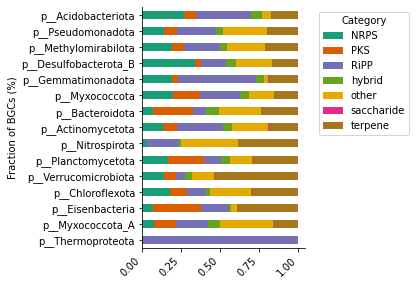

In [6]:
import matplotlib.pyplot as plt

# 将数据转换为适合画图的透视表
pivot_df = counts.pivot(index='phylum', columns='category', values='count').fillna(0)

# 添加一个新列：每个 phylum 的总 BGC 数量
pivot_df['total'] = pivot_df.sum(axis=1)

# 按总数排序，并取前20
pivot_top20 = pivot_df.sort_values('total', ascending=False).head(15)
pivot_top20 = pivot_top20.sort_values('total', ascending=True)

# 去掉 total 列（我们不需要在图中画出来）
pivot_top20 = pivot_top20.drop(columns='total')

pivot_percent = pivot_top20.div(pivot_top20.sum(axis=1), axis=0)

# 画堆叠柱状图
fig, ax = plt.subplots(figsize=(6, 4))
custom_colors = ['#1b9e77', '#d95f02', '#7570b3', '#66a61e', '#e6ab02', '#e7298a','#a6761d']
pivot_percent.plot(kind='barh', stacked=True,color=custom_colors,ax=ax)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('Fraction of BGCs (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

In [7]:
counts = df.groupby(['phylum', 'mag']).size().reset_index(name='count')
counts

,phylum,mag,count
0,p__ARS69,cpsnj11_SemiBin_122,2
1,p__ARS69,cpsnj14_SemiBin_7,3
2,p__ARS69,sample13_SemiBin_37,3
3,p__ARS69,sample13_SemiBin_38,4
4,p__ARS69,sample15_SemiBin_213,2
...,...,...,...
7453,p__Zhuqueibacterota,sample19_SemiBin_143,3
7454,p__Zhuqueibacterota,sample25_SemiBin_37,1
7455,p__Zhuqueibacterota,sample7_SemiBin_63,2
7456,p__Zixibacteria,sample19_SemiBin_217,1


In [8]:
phylum_avg = counts.groupby('phylum')['count'].mean().sort_values(ascending=False)
top_phylum = phylum_avg.head(10).index.tolist()

# 筛选top10 phylum的数据
top_data = counts[counts['phylum'].isin(top_phylum)]
top_data['phylum'] = pd.Categorical(top_data['phylum'], categories=top_phylum, ordered=True)
top_data

<ipython-input-8-0565a381019d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_data['phylum'] = pd.Categorical(top_data['phylum'], categories=top_phylum, ordered=True)


,phylum,mag,count
21,p__Acidobacteriota,cpsnj01_SemiBin_10,6
22,p__Acidobacteriota,cpsnj01_SemiBin_123,3
23,p__Acidobacteriota,cpsnj01_SemiBin_124,5
24,p__Acidobacteriota,cpsnj01_SemiBin_127,1
25,p__Acidobacteriota,cpsnj01_SemiBin_14,7
...,...,...,...
7447,p__Verrucomicrobiota,snj19_SemiBin_63,3
7448,p__Verrucomicrobiota,snj19_SemiBin_76,8
7449,p__Verrucomicrobiota,snj20_SemiBin_20,3
7450,p__Verrucomicrobiota,snj20_SemiBin_49,6


<ipython-input-9-8f2de9683e89>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.boxplot(data=top_data, x="phylum", y="count",palette="Blues",linewidth=1.5)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

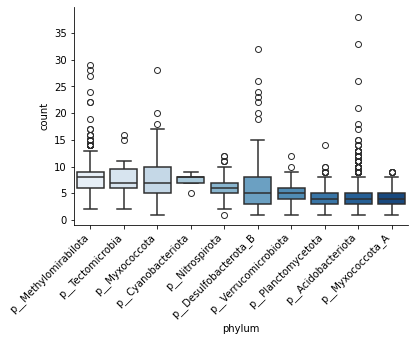

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
ax=sns.boxplot(data=top_data, x="phylum", y="count",palette="Blues",linewidth=1.5)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45, ha='right')